# M5 Real-Demand Replay — Multi-Echelon CA Example

**What this notebook shows:**

1. Ingest a CA-store slice from the raw M5 Kaggle files — a few items, a few stores, ~1 year.
2. Render a data-quality report; discuss what it shows.
3. Build a multi-echelon scenario: **invented factory → invented CA DC → emitted CA shops → replay sinks**.
4. Run with a textbook (s,S) policy at the shops; assert exact replay and zero `insufficient_cash` rejections.
5. Evaluate service level / lost sales / costs.
6. Event-overlay plot: demand series with calendar events and SNAP markers.
7. Optional variant: wrap the shop policy in `PriceReplayPolicy`.

**Data not included.** Raw M5 files are git-ignored. See `src/datasets/README.md` for download
instructions. When files are absent the notebook prints clear instructions and skips all cells
that require data — it does not error, and there is no CI dependency on real M5 data.

In [1]:
%matplotlib inline
import os
from pathlib import Path

# Hop up to the repo root so `import src...` resolves regardless of kernel cwd.
while not (Path.cwd() / "pyproject.toml").exists():
    os.chdir("..")

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 90
print("cwd:", Path.cwd())

cwd: /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator


## Step 1 — Locate raw M5 files (graceful exit if absent)

Download instructions: `src/datasets/README.md`.
Place the three CSV files (`sales_train_*.csv`, `sell_prices.csv`, `calendar.csv`) under `data/m5/`.

In [2]:
M5_DATA_DIR = Path("data/m5")

def _m5_files_present(data_dir: Path) -> bool:
    """Return True if all three M5 CSV files are present."""
    if not data_dir.is_dir():
        return False
    has_sales = any(
        f.name.startswith("sales_train") and f.suffix == ".csv"
        for f in data_dir.iterdir()
    )
    has_prices = (data_dir / "sell_prices.csv").exists()
    has_calendar = (data_dir / "calendar.csv").exists()
    return has_sales and has_prices and has_calendar


M5_AVAILABLE = _m5_files_present(M5_DATA_DIR)

if not M5_AVAILABLE:
    print(
        "\n"
        "Raw M5 files not found under data/m5/.\n"
        "\n"
        "To run this notebook end-to-end:\n"
        "  1. Download the M5 dataset from Kaggle:\n"
        "       https://www.kaggle.com/competitions/m5-forecasting-accuracy/data\n"
        "     or via the CLI: kaggle competitions download -c m5-forecasting-accuracy\n"
        "  2. Extract and place these files in data/m5/:\n"
        "       sales_train_validation.csv (or sales_train_evaluation.csv)\n"
        "       sell_prices.csv\n"
        "       calendar.csv\n"
        "  3. Re-run the notebook.\n"
        "\n"
        "Remaining cells are skipped gracefully. No assertions will be evaluated."
    )
else:
    print("M5 files found at", M5_DATA_DIR.resolve())

M5 files found at /Users/mislavjordanic/Documents/projects/personal_projects/supply_chain_simulator/data/m5


## Step 2 — Ingest a CA slice

Slice: a handful of CA items (fast movers from FOODS and HOUSEHOLD departments)
from three CA stores over ~1 year (2015-01-01 to 2015-12-31).

These choices are **scenario knobs** — authorial decisions, labeled as such so
it is clear what comes from the data versus what was invented.

In [3]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from datetime import date
    from src.datasets.m5 import load_m5_slice

    # ── Scenario knobs (authorial choices, labeled as such) ──────────────────
    ITEM_IDS = [
        "FOODS_3_090",     # high-velocity grocery
        "FOODS_3_586",     # another grocery fast-mover
        "HOUSEHOLD_1_108", # household consumable
    ]
    STORE_IDS  = ["CA_1", "CA_2", "CA_3"]
    START_DATE = date(2015, 1, 1)
    END_DATE   = date(2015, 12, 31)  # ~1 year = 365 ticks
    # ─────────────────────────────────────────────────────────────────────────

    m5 = load_m5_slice(
        data_dir=M5_DATA_DIR,
        item_ids=ITEM_IDS,
        store_ids=STORE_IDS,
        start_date=START_DATE,
        end_date=END_DATE,
    )

    print(f"Slice: {len(m5.item_ids)} items × {len(m5.store_ids)} stores × {m5.n_ticks} ticks")
    print(f"Date window: {m5.start_date} → {m5.end_date}")
    print(f"Item → dept : {m5.item_dept}")
    print(f"Store → state: {m5.store_state}")

Slice: 3 items × 3 stores × 365 ticks
Date window: 2015-01-01 → 2015-12-31
Item → dept : {'HOUSEHOLD_1_108': 'HOUSEHOLD_1', 'FOODS_3_090': 'FOODS_3', 'FOODS_3_586': 'FOODS_3'}
Store → state: {'CA_1': 'CA', 'CA_2': 'CA', 'CA_3': 'CA'}


## Step 3 — Data-quality report

**Columns:**
- `price_coverage_pct` — fraction of days with a positive (observed) price.
- `ffill_count` / `bfill_count` — days whose price was gap-filled. Forward-fill propagates the
  last known weekly price forward; back-fill patches pre-launch leading gaps with the first known
  price. High fill counts mean fabricated prices — explicit and visible, not silent.
- `zero_sale_day_share` — fraction of days with zero sales.
- `longest_zero_run` — longest consecutive run of zero-sale days. Long runs are the chief
  indicator of suspected out-of-stock periods.
- `launch_date` — first day with a positive sale in this window.

**Censoring caveat:** M5 records *sales*, not *demand*. On days when the shelf was empty,
the series reads zero even if customers wanted the product. The quality report's `longest_zero_run`
column flags suspected out-of-stock periods. For pure replay, choose items where zero runs are
short — those are items that were continuously available so observed sales ≈ true demand.

In [4]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.datasets.m5 import quality_report

    qr = quality_report(m5)
    print("Quality report:")
    display(qr)

    print()
    print("Mean zero_sale_day_share :", qr["zero_sale_day_share"].mean().round(3))
    print("Mean longest_zero_run    :", qr["longest_zero_run"].mean().round(1))
    print("Max  longest_zero_run    :", qr["longest_zero_run"].max())
    print()
    print(
        "Interpretation: long zero runs (>7 days) suggest suspected OOS periods.\n"
        "Items with short zero runs are safest for replay — observed sales ≈ true demand."
    )

Quality report:


,item_id,store_id,price_coverage_pct,ffill_count,bfill_count,zero_sale_day_share,longest_zero_run,launch_date
0,FOODS_3_090,CA_1,100.0,0,0,0.249315,31,2015-01-04
1,FOODS_3_090,CA_2,100.0,0,0,0.254795,31,2015-01-04
2,FOODS_3_090,CA_3,100.0,0,0,0.134247,6,2015-01-05
3,FOODS_3_586,CA_1,100.0,0,0,0.002740,1,2015-01-01
4,FOODS_3_586,CA_2,100.0,0,0,0.002740,1,2015-01-01
5,FOODS_3_586,CA_3,100.0,0,0,0.002740,1,2015-01-01
6,HOUSEHOLD_1_108,CA_1,100.0,0,0,0.882192,69,2015-01-05
7,HOUSEHOLD_1_108,CA_2,100.0,0,0,0.873973,21,2015-01-19
8,HOUSEHOLD_1_108,CA_3,100.0,0,0,0.846575,41,2015-01-05



Mean zero_sale_day_share : 0.361
Mean longest_zero_run    : 22.4
Max  longest_zero_run    : 69

Interpretation: long zero runs (>7 days) suggest suspected OOS periods.
Items with short zero runs are safest for replay — observed sales ≈ true demand.


## Step 4 — Emit the M5 setup directory (shops + replay sinks)

`emit_m5_setup_dir` writes one shop per CA store and one replay-demand sink per (item, store),
plus the catalog, `setup.yaml`, and supporting parquet files.
No upstream nodes are emitted — those are the "invented" part the notebook adds next.

In [5]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.datasets.m5 import emit_m5_setup_dir

    M5_SETUP_DIR = Path("data/notebook_demos/m5_replay/m5_base_setup")
    M5_SETUP_DIR.mkdir(parents=True, exist_ok=True)

    emit_m5_setup_dir(
        m5_slice=m5,
        data_dir=M5_DATA_DIR,
        setup_dir=M5_SETUP_DIR,
        unit_cost_fraction=0.40,  # scenario knob: unit_cost = 40% of base_price (explicit fiction)
        world_seed=42,
    )

    written = sorted(str(p.relative_to(M5_SETUP_DIR)) for p in M5_SETUP_DIR.rglob("*") if p.is_file())
    print("Files in setup dir:")
    for f in written:
        print(" ", f)

Files in setup dir:
  calendar.parquet
  catalog.csv
  demand_series.parquet
  prices.parquet
  quality_report.parquet
  setup.yaml


## Step 5 — Build the multi-echelon topology (ii)

The M5 setup dir has shops and replay sinks. Now we layer in the invented upstream:

```
factory-FOODS_3_090  factory-FOODS_3_586  factory-HOUSEHOLD_1_108
        \                   |                    /
         \──── lead=5 ──────┼───── lead=5 ──────/   (invented lead times)
                            ▼
                          dc-CA                    ← invented CA distribution centre
                    /──lead=2──┼──lead=2──\
                   ▼           ▼           ▼
               shop-CA_1  shop-CA_2  shop-CA_3    (emitted by emit_m5_setup_dir)
                  │           │           │
               sinks       sinks       sinks      (replay series attached)
```

**Invented params are labeled explicitly as scenario knobs.**

In [6]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.sim.setup_io import load_setup, _derive_node_seed
    from src.sim.node import FactoryNode, IntermediateNode
    from src.sim.scenario import NodeInstance, Scenario
    from src.sim.graph import EdgeSpec

    # Load the base scenario emitted by emit_m5_setup_dir.
    base_scenario = load_setup(M5_SETUP_DIR)

    print("Base scenario nodes:")
    for ni in base_scenario.nodes:
        print(f"  {ni.node.id:50s}  {type(ni.node).__name__}")
    print(f"\nn_steps = {base_scenario.n_steps}, start_date = {base_scenario.start_date}")

Base scenario nodes:
  shop-CA_1                                           IntermediateNode
  sink-FOODS_3_090-CA_1                               ReplayDemandSinkNode
  sink-FOODS_3_586-CA_1                               ReplayDemandSinkNode
  sink-HOUSEHOLD_1_108-CA_1                           ReplayDemandSinkNode
  shop-CA_2                                           IntermediateNode
  sink-FOODS_3_090-CA_2                               ReplayDemandSinkNode
  sink-FOODS_3_586-CA_2                               ReplayDemandSinkNode
  sink-HOUSEHOLD_1_108-CA_2                           ReplayDemandSinkNode
  shop-CA_3                                           IntermediateNode
  sink-FOODS_3_090-CA_3                               ReplayDemandSinkNode
  sink-FOODS_3_586-CA_3                               ReplayDemandSinkNode
  sink-HOUSEHOLD_1_108-CA_3                           ReplayDemandSinkNode

n_steps = 365, start_date = 2015-01-01 00:00:00


In [7]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # ── Invented upstream knobs (explicit, labeled) ───────────────────────────
    FACTORY_CAPACITY_PER_TICK = 500    # invented: factory can produce 500 units/tick
    DC_CAPACITY               = 50_000  # invented: DC can hold 50k units across all SKUs
    FACTORY_TO_DC_LEAD_TIME   = 5      # invented: 5-day transit from factory to DC
    DC_TO_SHOP_LEAD_TIME      = 2      # invented: 2-day transit from DC to shops
    DC_PRESTOCK_PER_PID       = 2_000  # invented: DC opening stock per product
    SHOP_PRESTOCK_PER_PID     = 500    # invented: shop opening stock per product (~2 weeks)
    SHOP_WORKING_CAPITAL      = 500_000.0  # invented: shop opening cash
    # ─────────────────────────────────────────────────────────────────────────

    WORLD_SEED  = 42
    product_ids = [w.product_id for w in base_scenario.catalog]

    # One factory per product (simplest topology; author choice).
    factory_nodes = []
    for ware in base_scenario.catalog:
        pid = ware.product_id
        fid   = f"factory-{pid}"
        fseed = _derive_node_seed(WORLD_SEED, fid)
        factory = FactoryNode(
            id=fid,
            region="CA",  # invented: factory in CA region
            init_seed=fseed,
            produces_product_id=pid,
            unit_cost=ware.unit_cost,
            capacity_per_tick=FACTORY_CAPACITY_PER_TICK,
            inventory=FACTORY_CAPACITY_PER_TICK * 10,  # pre-stocked
            list_price=ware.unit_cost,  # zero-margin factory (ADR 0013)
            cash=0.0,
        )
        factory_nodes.append(NodeInstance(node=factory, init_seed=fseed, policy=None))

    # One DC for all CA stores.
    dc_id   = "dc-CA"
    dc_seed = _derive_node_seed(WORLD_SEED, dc_id)
    dc_node = IntermediateNode(
        id=dc_id,
        region="CA",
        init_seed=dc_seed,
        carried_products=set(product_ids),
        capacity=DC_CAPACITY,
        tags=["dc"],
        inventory={pid: DC_PRESTOCK_PER_PID for pid in product_ids},  # invented pre-stock
        list_prices={w.product_id: w.base_price for w in base_scenario.catalog},
        min_order_imposed={pid: 0 for pid in product_ids},
        cash=1_000_000.0,  # invented: DC starts with working capital
    )
    dc_instance = NodeInstance(node=dc_node, init_seed=dc_seed, policy=None)

    # Emitted shops have zero inventory and zero cash — working capital and
    # opening stock are the scenario author's job, like the upstream topology.
    # Without cash a shop can never buy from the DC (the policy's purchase
    # budget is a fraction of on-hand cash), so every unit of demand is lost.
    for ni in base_scenario.nodes:
        if isinstance(ni.node, IntermediateNode):  # shops
            ni.node.cash = SHOP_WORKING_CAPITAL
            ni.node.inventory = {pid: SHOP_PRESTOCK_PER_PID for pid in product_ids}

    print(f"Added: {len(factory_nodes)} factory nodes + 1 DC ({dc_id})")
    print(f"Stocked shops: {SHOP_PRESTOCK_PER_PID} units/product, cash {SHOP_WORKING_CAPITAL:,.0f}")
    print(f"Products: {product_ids}")

Added: 3 factory nodes + 1 DC (dc-CA)
Stocked shops: 500 units/product, cash 500,000
Products: ['FOODS_3_090', 'FOODS_3_586', 'HOUSEHOLD_1_108']


In [8]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Build edge list: factory → DC, DC → each shop.
    new_edges: list[EdgeSpec] = []

    # factory-<pid> → dc-CA  (one edge per product)
    for ware in base_scenario.catalog:
        new_edges.append(EdgeSpec(
            supplier_id=f"factory-{ware.product_id}",
            buyer_id=dc_id,
            default_lead_time=FACTORY_TO_DC_LEAD_TIME,
        ))

    # dc-CA → shop-CA_x  (one edge per shop; shops already wired to sinks)
    shop_ids = [f"shop-{sid}" for sid in STORE_IDS]
    for shop_id in shop_ids:
        new_edges.append(EdgeSpec(
            supplier_id=dc_id,
            buyer_id=shop_id,
            default_lead_time=DC_TO_SHOP_LEAD_TIME,
        ))

    print("New edges (factory→DC + DC→shop):")
    for e in new_edges:
        print(f"  {e.supplier_id:40s} → {e.buyer_id:20s}  lead={e.default_lead_time}")

New edges (factory→DC + DC→shop):
  factory-FOODS_3_090                      → dc-CA                 lead=5
  factory-FOODS_3_586                      → dc-CA                 lead=5
  factory-HOUSEHOLD_1_108                  → dc-CA                 lead=5
  dc-CA                                    → shop-CA_1             lead=2
  dc-CA                                    → shop-CA_2             lead=2
  dc-CA                                    → shop-CA_3             lead=2


In [9]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Assemble full scenario: upstream nodes + base scenario nodes/edges.
    all_nodes = factory_nodes + [dc_instance] + list(base_scenario.nodes)
    all_edges = new_edges + list(base_scenario.edges)

    full_scenario = Scenario(
        catalog=base_scenario.catalog,
        market=base_scenario.market,
        disruption=base_scenario.disruption,
        item_lifecycle=base_scenario.item_lifecycle,
        nodes=all_nodes,
        edges=all_edges,
        n_steps=base_scenario.n_steps,
        start_date=base_scenario.start_date,
        world_seed=WORLD_SEED,
    )

    # Summarize by node type.
    from src.sim.node import FactoryNode as _F, IntermediateNode as _I
    from src.sim.replay_demand_sink import ReplayDemandSinkNode as _R
    n_factories = sum(1 for ni in full_scenario.nodes if isinstance(ni.node, _F))
    n_inter     = sum(1 for ni in full_scenario.nodes if isinstance(ni.node, _I))
    n_sinks     = sum(1 for ni in full_scenario.nodes if isinstance(ni.node, _R))
    print(f"Full scenario: {len(full_scenario.nodes)} nodes, {len(full_scenario.edges)} edges")
    print(f"  FactoryNode      : {n_factories}")
    print(f"  IntermediateNode : {n_inter}   (DC + shops)")
    print(f"  ReplayDemandSink : {n_sinks}")

Full scenario: 16 nodes, 15 edges
  FactoryNode      : 3
  IntermediateNode : 4   (DC + shops)
  ReplayDemandSink : 9


## Step 6 — Attach textbook (s,S) policy to shops and DC

`OrderUpToPolicy` is a standard (s,S) continuous-review textbook policy: review every tick,
reorder when position < s, bring position up to S.
Factories have no policy — they produce from pre-stocked inventory on demand.

In [10]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.sim.policy import OrderUpToPolicy

    # Policy hyperparams — declared as scenario knobs.  Deliberately
    # conservative: real M5 demand is spiky, so we hold a generous safety
    # margin to make stockouts unlikely (at the cost of higher holding stock).
    COVER_HORIZON_TICKS    = 21   # order enough to cover 21 days of demand
    SAFETY_LEAD_PCT_OF_LAG = 1.0  # safety stock = full lead time × rate
    STOCKOUT_SAFETY_BONUS  = 1.0  # extend safety by another lead time after a stockout

    for ni in full_scenario.nodes:
        node = ni.node
        if isinstance(node, _I):  # shops and DC
            pseed = _derive_node_seed(WORLD_SEED, node.id, "policy")
            ni.policy = OrderUpToPolicy(
                policy_seed=pseed,
                cover_horizon_ticks=COVER_HORIZON_TICKS,
                safety_lead_pct_of_lag=SAFETY_LEAD_PCT_OF_LAG,
                stockout_safety_bonus_pct_of_lag=STOCKOUT_SAFETY_BONUS,
            )

    attached = [ni.node.id for ni in full_scenario.nodes if ni.policy is not None]
    print("OrderUpToPolicy attached to:", attached)

OrderUpToPolicy attached to: ['dc-CA', 'shop-CA_1', 'shop-CA_2', 'shop-CA_3']


## Step 7 — Run the simulation and assert exact replay

Under a flat world (multiplier chain = 1.0 everywhere), `demand_target = series[tick]` exactly.

**Inline assertions:**
1. Per-tick sink demand in the `node_flows` log == M5 series value for that tick (exact replay).
   Sink demand is read from `node_flows` (ADR 0019); `node_orders` only covers intermediate
   buyers and never contains sinks.
2. Zero `insufficient_cash` rejections at sinks (adapter sets income_rate high enough).

In [11]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.sim.runner import Runner

    print(f"Running {full_scenario.n_steps} ticks...")
    run_log = Runner(full_scenario).run()
    print(f"Done. n_steps = {run_log['n_steps']}")

Running 365 ticks...


Done. n_steps = 365


In [12]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # ── Assertion 1: exact replay ─────────────────────────────────────────────
    # For each replay sink, the per-tick demand logged in the run log must match
    # the series value for that tick.
    # Sink demand lives in the ``node_flows`` rows (ADR 0019) — ``node_orders``
    # only covers intermediate buyers and never contains sinks.

    from src.sim.replay_demand_sink import ReplayDemandSinkNode

    # Build a map: sink_id → (product_id, series)
    sink_map: dict[str, tuple[str, list[int]]] = {
        ni.node.id: (ni.node.product_id, ni.node.series)
        for ni in full_scenario.nodes
        if isinstance(ni.node, ReplayDemandSinkNode)
    }

    replay_mismatches = []
    for tick_data in run_log["ticks"]:
        tick = tick_data["tick"]           # 1-based
        flow_demand = {
            (f["node_id"], f["pid"]): f["demand"]
            for f in tick_data["node_flows"]
        }
        for sink_id, (pid, series) in sink_map.items():
            expected = series[tick - 1]    # 0-indexed series
            actual   = flow_demand.get((sink_id, pid), 0)
            if actual != expected:
                replay_mismatches.append({
                    "tick": tick, "sink_id": sink_id, "pid": pid,
                    "expected": expected, "actual": actual,
                })

    if replay_mismatches:
        print(f"REPLAY MISMATCH: {len(replay_mismatches)} mismatches found")
        display(pd.DataFrame(replay_mismatches).head(10))
    else:
        print(
            f"PASS: exact replay verified across all {len(sink_map)} sinks "
            f"× {run_log['n_steps']} ticks"
        )

    assert not replay_mismatches, "Exact replay failed — see mismatches above"

PASS: exact replay verified across all 9 sinks × 365 ticks


In [13]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # ── Assertion 2: zero insufficient_cash sink rejections ───────────────────
    all_rejections = [
        {**r, "tick": t["tick"]}
        for t in run_log["ticks"]
        for r in t["rejections"]
    ]
    rej_df = pd.DataFrame(all_rejections) if all_rejections else pd.DataFrame(
        columns=["tick", "buyer_id", "supplier_id", "pid",
                 "qty_requested", "qty_filled", "qty_rejected", "reason"]
    )

    sink_ids = set(sink_map.keys())
    sink_rej  = rej_df[rej_df["buyer_id"].isin(sink_ids)] if len(rej_df) > 0 else rej_df
    cash_rej  = sink_rej[sink_rej["reason"] == "insufficient_cash"] if len(sink_rej) > 0 else sink_rej

    if len(cash_rej) > 0:
        print(f"FAIL: {len(cash_rej)} insufficient_cash rejections at sinks")
        display(cash_rej.head())
        assert False, "insufficient_cash rejections found at replay sinks"
    else:
        print("PASS: zero insufficient_cash rejections at replay sinks")

PASS: zero insufficient_cash rejections at replay sinks


## Step 8 — Evaluate: service level, lost sales, costs

The rejection log is the primary evaluation tool.
- `unmet_demand` entries (supplier_id = None) are true lost sales — no feasible upstream could fill.
- `insufficient_stock` entries indicate stockouts at the shop before the order was placed.

In [14]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    from src.sim.inspect import node_timeseries_df, flow_frame
    from src.sim.metrics import business_metrics

    ts   = node_timeseries_df(run_log, full_scenario)
    ff   = flow_frame(run_log)
    kpis = business_metrics(ff, ts, full_scenario)
    print("Business KPIs:")
    display(kpis)

Business KPIs:


,node_id,service_level,stockout_rate,inventory_turnover,mean_price_pct_of_msrp
0,factory-FOODS_3_090,1.0,0.000000,1.951082,0.40
1,factory-FOODS_3_586,1.0,0.000000,1.318544,0.40
2,factory-HOUSEHOLD_1_108,0.0,0.000000,0.000000,0.40
3,dc-CA,1.0,0.002740,3.879793,1.00
4,shop-CA_1,1.0,0.000000,13.299842,1.00
5,shop-CA_2,1.0,0.000000,12.058013,1.00
6,shop-CA_3,1.0,0.000000,15.149104,1.00
7,_system,1.0,0.000548,11.874199,0.88


In [15]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Rejection breakdown (all reasons).
    if len(rej_df) > 0:
        print("All rejection reasons (count):")
        display(rej_df["reason"].value_counts().rename("count").to_frame())
    else:
        print("No rejections at all — every order was filled in full.")

    # Service level per shop.
    print("\n=== Service-level per shop ===")
    unmet = rej_df[rej_df["reason"] == "unmet_demand"] if len(rej_df) > 0 else rej_df

    # Map sink → shop via edges.
    sink_to_shop: dict[str, str] = {
        e.buyer_id: e.supplier_id
        for e in full_scenario.edges
        if e.buyer_id in sink_ids
    }

    shop_ids = [f"shop-{sid}" for sid in STORE_IDS]
    for shop_id in shop_ids:
        sinks_for_shop = [sid for sid, sh in sink_to_shop.items() if sh == shop_id]
        total_demanded = sum(
            sum(sink_map[sid][1]) for sid in sinks_for_shop if sid in sink_map
        )
        lost = 0
        if len(unmet) > 0:
            lost = int(unmet[unmet["buyer_id"].isin(sinks_for_shop)]["qty_rejected"].sum())
        svc = 1.0 - lost / total_demanded if total_demanded > 0 else 1.0
        print(f"  {shop_id}: demand={total_demanded:6d}  lost_units={lost:4d}  service_level={svc:.1%}")

All rejection reasons (count):


,count
reason,
unmet_demand,2



=== Service-level per shop ===
  shop-CA_1: demand= 34893  lost_units=   5  service_level=100.0%
  shop-CA_2: demand= 23945  lost_units=   0  service_level=100.0%
  shop-CA_3: demand= 60137  lost_units=  10  service_level=100.0%


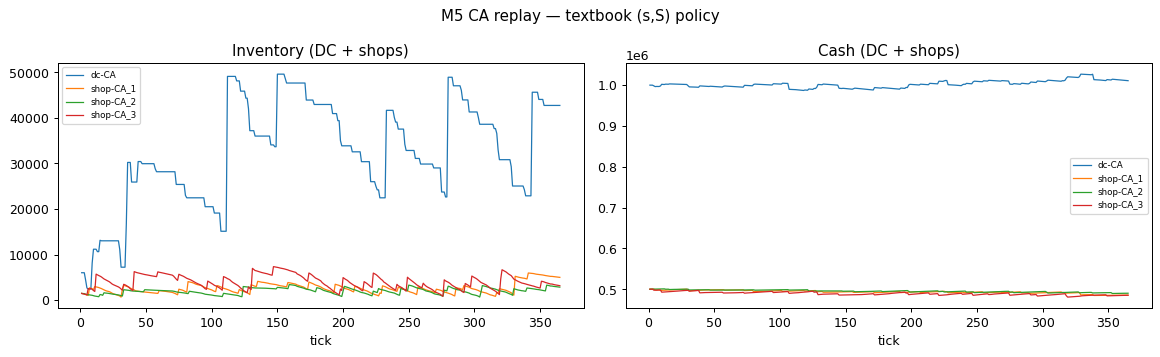

In [16]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Inventory and cash over time for the DC and shops.
    intermediate_ids = [dc_id] + shop_ids
    ts_inter = ts[ts["node_id"].isin(intermediate_ids)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for nid, g in ts_inter.groupby("node_id"):
        axes[0].plot(g["tick"], g["inventory_total"], label=nid, lw=1)
        axes[1].plot(g["tick"], g["cash"],            label=nid, lw=1)
    axes[0].set_title("Inventory (DC + shops)"); axes[0].set_xlabel("tick")
    axes[1].set_title("Cash (DC + shops)");      axes[1].set_xlabel("tick")
    for ax in axes:
        ax.legend(fontsize=7)
    fig.suptitle("M5 CA replay — textbook (s,S) policy")
    plt.tight_layout()
    plt.show()

## Step 9 — Event-overlay plot

The emitted setup directory includes `calendar.parquet` with all calendar rows in the slice window,
including event names and SNAP flags (EBT/food-stamp benefit days). This cell reads that file and
overlays calendar events on the demand series for one (item, store) pair.

**Visualization only** — calendar events are not wired to the simulation engine. They are preserved
on disk for a future calibration effort (e.g., fitting a seasonal multiplier to SNAP days).

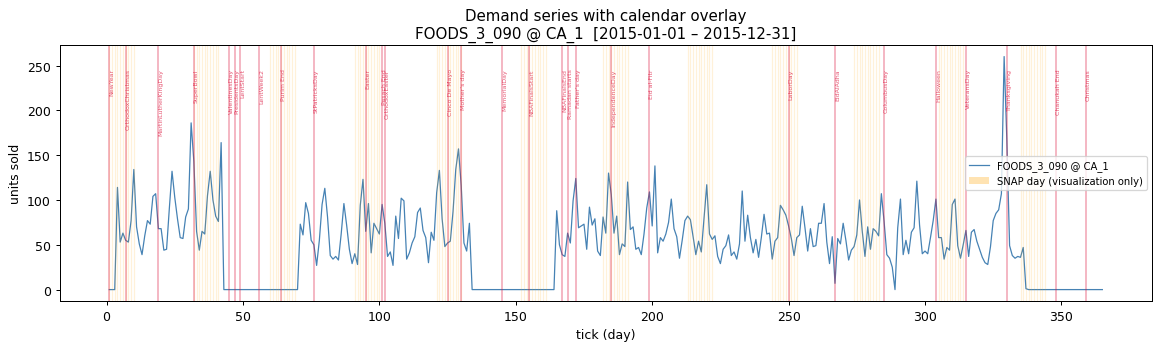

Note: SNAP days and calendar events are visualization overlays only.
They are not wired to the simulation engine — preserved on disk for future calibration.


In [17]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Event-overlay: demand series for the first item at CA_1, with event markers.
    OVERLAY_ITEM  = ITEM_IDS[0]   # e.g. "FOODS_3_090"
    OVERLAY_STORE = STORE_IDS[0]  # "CA_1"

    demand_series = m5.sales.get((OVERLAY_ITEM, OVERLAY_STORE), [])

    cal_path = M5_SETUP_DIR / "calendar.parquet"
    if not cal_path.exists() or not demand_series:
        print("calendar.parquet not found or empty demand series — skipping event overlay.")
    else:
        cal_df = pd.read_parquet(cal_path)
        cal_df["date"] = pd.to_datetime(cal_df["date"])

        start_ts = pd.Timestamp(START_DATE)
        cal_df["tick"] = (cal_df["date"] - start_ts).dt.days + 1

        ticks_range = list(range(1, len(demand_series) + 1))
        y_max = max(demand_series) if demand_series else 1

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(ticks_range, demand_series,
                color="steelblue", lw=1,
                label=f"{OVERLAY_ITEM} @ {OVERLAY_STORE}")

        legend_extra = []

        # Shade SNAP days (EBT benefit days for this state).
        snap_col = f"snap_{OVERLAY_STORE[:2]}"   # e.g. "snap_CA"
        if snap_col in cal_df.columns:
            snap_ticks = cal_df[cal_df[snap_col] == "1"]["tick"].values
            for st in snap_ticks:
                ax.axvline(x=st, color="orange", alpha=0.15, lw=1)
            from matplotlib.patches import Patch
            legend_extra.append(
                Patch(facecolor="orange", alpha=0.3, label="SNAP day (visualization only)")
            )

        # Mark named calendar events (holidays, sporting events, etc.).
        event_col = "event_name_1" if "event_name_1" in cal_df.columns else None
        if event_col:
            events = cal_df[cal_df[event_col].notna() & (cal_df[event_col] != "")]
            for _, ev_row in events.iterrows():
                tick_val = ev_row["tick"]
                ev_name  = ev_row[event_col]
                ax.axvline(x=tick_val, color="crimson", alpha=0.4, lw=1.2)
                ax.text(tick_val, y_max * 0.95, ev_name,
                        rotation=90, fontsize=5, color="crimson", va="top", alpha=0.7)

        ax.set_title(
            f"Demand series with calendar overlay\n"
            f"{OVERLAY_ITEM} @ {OVERLAY_STORE}  [{START_DATE} – {END_DATE}]"
        )
        ax.set_xlabel("tick (day)")
        ax.set_ylabel("units sold")
        handles, _ = ax.get_legend_handles_labels()
        ax.legend(handles=handles + legend_extra, fontsize=8)
        plt.tight_layout()
        plt.show()

        print(
            "Note: SNAP days and calendar events are visualization overlays only.\n"
            "They are not wired to the simulation engine — preserved on disk for future calibration."
        )

## Step 10 — Optional variant: PriceReplayPolicy

Wrap each shop's ordering policy with `PriceReplayPolicy` so the shop offers items at the
observed M5 daily price rather than the catalog `base_price`. Ordering decisions are
unchanged — only the `list_price` portion of the shop's action is overwritten.

This block is independent of the assertions above and can be skipped without
affecting the replay verification.

In [18]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    import copy
    from src.sim.policy import PriceReplayPolicy, OrderUpToPolicy

    def _make_price_dict(store_id: str) -> dict[str, list[float]]:
        """Build {pid: [price_tick0, price_tick1, ...]} for this store."""
        return {
            item_id: list(prices)
            for item_id in m5.item_ids
            if (prices := m5.prices.get((item_id, store_id)))
        }

    # Deep-copy so assertions in Step 7 are unaffected.
    price_scenario = copy.deepcopy(full_scenario)

    for ni in price_scenario.nodes:
        node = ni.node
        if not isinstance(node, _I):
            continue
        pseed = _derive_node_seed(WORLD_SEED, node.id, "policy")
        inner = OrderUpToPolicy(
            policy_seed=pseed,
            cover_horizon_ticks=COVER_HORIZON_TICKS,
            safety_lead_pct_of_lag=SAFETY_LEAD_PCT_OF_LAG,
            stockout_safety_bonus_pct_of_lag=STOCKOUT_SAFETY_BONUS,
        )
        if node.id in shop_ids:  # shops get the price-replay wrapper
            store_id   = node.id.removeprefix("shop-")
            price_dict = _make_price_dict(store_id)
            if price_dict:
                ni.policy = PriceReplayPolicy(
                    inner=inner,
                    prices=price_dict,
                    n_steps=price_scenario.n_steps,
                )
                print(f"  {node.id}: PriceReplayPolicy wrapping (s,S) — {len(price_dict)} products")
                continue
        ni.policy = inner  # DC and shops without price data get plain (s,S)

    print("\nRunning price-replay variant...")
    price_run_log = Runner(price_scenario).run()
    print(f"Done. n_steps = {price_run_log['n_steps']}")

  shop-CA_1: PriceReplayPolicy wrapping (s,S) — 3 products
  shop-CA_2: PriceReplayPolicy wrapping (s,S) — 3 products
  shop-CA_3: PriceReplayPolicy wrapping (s,S) — 3 products

Running price-replay variant...
Done. n_steps = 365


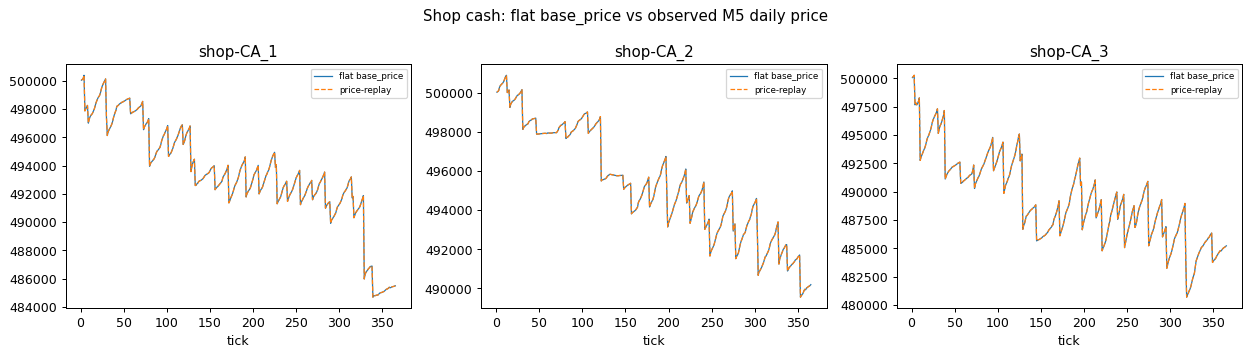

Observation: price-replay cash trajectory differs from flat-price because shops
now receive the real observed prices — week-to-week price variation flows through the simulator's revenue accounting.


In [19]:
if not M5_AVAILABLE:
    print("[skipped — M5 data absent]")
else:
    # Compare shop cash: flat base_price vs observed M5 price replay.
    ts_price = node_timeseries_df(price_run_log, price_scenario)
    ts_base  = ts

    fig, axes = plt.subplots(1, len(shop_ids), figsize=(14, 4), sharey=False)
    if len(shop_ids) == 1:
        axes = [axes]

    for ax, shop_id in zip(axes, shop_ids):
        base_g  = ts_base [ts_base ["node_id"] == shop_id]
        price_g = ts_price[ts_price["node_id"] == shop_id]
        ax.plot(base_g ["tick"], base_g ["cash"], label="flat base_price",  lw=1)
        ax.plot(price_g["tick"], price_g["cash"], label="price-replay",     lw=1, ls="--")
        ax.set_title(shop_id); ax.set_xlabel("tick"); ax.legend(fontsize=7)

    fig.suptitle("Shop cash: flat base_price vs observed M5 daily price")
    plt.tight_layout()
    plt.show()

    print(
        "Observation: price-replay cash trajectory differs from flat-price because shops\n"
        "now receive the real observed prices — week-to-week price variation flows through"
        " the simulator's revenue accounting."
    )

## Summary

This notebook demonstrated the full M5 replay pipeline:

1. **Raw M5 → slice → quality report:** `load_m5_slice` + `quality_report` give a clear view of
   price coverage, fill counts, and zero-sale patterns before committing to a scenario.
   **Censoring caveat** stated: M5 records sales, not demand — short zero runs = safest slices.

2. **Emit setup dir:** `emit_m5_setup_dir` converts the slice to a standard ADR 0017 setup directory
   (shops + replay sinks; no upstream — that is the author's job).

3. **Author upstream:** a factory and CA DC were added in Python using the same `NodeInstance` /
   `EdgeSpec` API used by all other scenarios. **Invented params are labeled as scenario knobs.**

4. **Exact replay verified:** under a flat world, every sink's per-tick order matches its M5 series
   exactly. Zero `insufficient_cash` rejections.

5. **Service-level evaluation:** the rejection log quantifies lost sales under the textbook
   (s,S) policy against real demand.

6. **Event overlay:** calendar events and SNAP days are visualized on the demand series —
   preserved on disk for future calibration, not wired to the engine.

7. **Price-replay variant:** `PriceReplayPolicy` makes shops offer items at the observed M5
   daily price, showing how real price variation flows through simulator revenue accounting.